# S6 — Bonus: hands-on with a public dataset (GSE106118)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/enriquea/ZebraQ/blob/main/lessons-py/S6_Bonus_GSE106118.ipynb)

**ZebraQ — Introduction to Python and bulk RNA-seq data analysis**

Everything so far used data we prepared for you. This notebook takes a dataset
straight from a public repository and walks the whole way from raw file to
biological result.

**GSE106118** profiles human fetal hearts. Each sample comes from one of the four
chambers: left atrium (LA), right atrium (RA), left ventricle (LV), right
ventricle (RV). We ask which genes distinguish the chambers.

You will practise: parsing a real file, deriving metadata from sample names, QC,
filtering, transformation, correlation, group comparison, and exporting a
multi-sheet Excel report.

## 0. Setup

In [1]:
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "pandas", "seaborn", "scipy", "statsmodels", "openpyxl"],
        check=True,
    )

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RAW = "https://raw.githubusercontent.com/enriquea/ZebraQ/main/data/"


def data_path(fname):
    local = Path("../data") / fname
    return local if local.exists() else RAW + fname


OUT = Path("../results/py")
OUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Read the data

The file is gzip-compressed. pandas decompresses it automatically from the
`.gz` extension — no unzipping, and no helper function needed.

> The R lesson writes a small `read_expr()` function to dispatch on the file
> extension. `pd.read_csv` already does that for you.

In [2]:
raw_df = pd.read_csv(data_path("GSE106118_HE10W.tsv.gz"), sep="\t")

print(f"{raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print(f"first columns: {list(raw_df.columns[:6])}")
raw_df.iloc[:5, :6]

24,153 rows x 194 columns
first columns: ['Gene', 'LA1', 'LA2', 'LA3', 'LA4', 'LA5']


,Gene,LA1,LA2,LA3,LA4,LA5
0,A1BG,0.0,0.0,0.0,0.0,0.0
1,A1BG-AS1,0.0,0.0,0.0,0.0,0.0
2,A1CF,0.0,0.0,0.0,0.0,0.0
3,A2M,0.0,0.0,0.0,0.0,0.0
4,A2M-AS1,0.0,0.0,0.0,0.0,0.0


### 1.1 Clean the column names

Files that have been through a spreadsheet often pick up stray whitespace in
their headers. Strip it before anything else — a trailing space in a column name
causes errors that are very hard to spot.

In [3]:
before = list(raw_df.columns[:3])
raw_df.columns = (
    raw_df.columns.str.replace(r"\s+", "", regex=True)
    .str.replace(r"\.+", ".", regex=True)
)
print(f"before: {before}")
print(f"after : {list(raw_df.columns[:3])}")

assert "Gene" in raw_df.columns, "expected a 'Gene' column"

before: ['Gene', 'LA1', 'LA2']
after : ['Gene', 'LA1', 'LA2']


### 1.2 Build the expression matrix

Genes as rows, samples as columns. Duplicate gene symbols would break the index,
so we drop them first.

In [4]:
dupes = raw_df["Gene"].duplicated().sum()
print(f"duplicated gene names: {dupes}")

expr = (
    raw_df.drop_duplicates(subset="Gene")
    .set_index("Gene")
    .apply(pd.to_numeric, errors="coerce")
)

print(f"expression matrix: {expr.shape[0]:,} genes x {expr.shape[1]} samples")
print(f"missing values   : {expr.isna().sum().sum():,}")
expr.iloc[:3, :6]

duplicated gene names: 0
expression matrix: 24,153 genes x 193 samples
missing values   : 0


,LA1,LA2,LA3,LA4,LA5,LA6
Gene,,,,,,
A1BG,0.0,0.0,0.0,0.0,0.0,0.0
A1BG-AS1,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Derive the sample metadata

There is no samplesheet — the experimental design is encoded in the sample names
(`LA1`, `LA2`, `RV7`, …). Extracting it with a regular expression is a very
common real-world task.

In [5]:
samples = pd.Series(expr.columns, name="sample")

meta = pd.DataFrame({
    "sample": samples,
    "chamber": samples.str.extract(r"^([A-Z]{2})", expand=False),
    "replicate": pd.to_numeric(samples.str.extract(r"(\d+)", expand=False)),
}).set_index("sample")

print(meta["chamber"].value_counts().sort_index())
print(f"\nany sample we failed to parse? {meta['chamber'].isna().sum()}")
meta.head()

chamber
LA    48
LV    48
RA    49
RV    48
Name: count, dtype: int64

any sample we failed to parse? 0


,chamber,replicate
sample,,
LA1,LA,1
LA2,LA,2
LA3,LA,3
LA4,LA,4
LA5,LA,5


Give the chambers a sensible order so that every figure below is consistent:
atria first, then ventricles; left before right.

In [6]:
CHAMBERS = ["LA", "RA", "LV", "RV"]
meta["chamber"] = pd.Categorical(meta["chamber"], categories=CHAMBERS, ordered=True)
PALETTE = dict(zip(CHAMBERS, sns.color_palette("Set2", 4)))
print(f"chamber order: {CHAMBERS}")

chamber order: ['LA', 'RA', 'LV', 'RV']


## 3. Quality control

The total signal per sample should be broadly similar. A sample that is wildly
off is a candidate for exclusion.

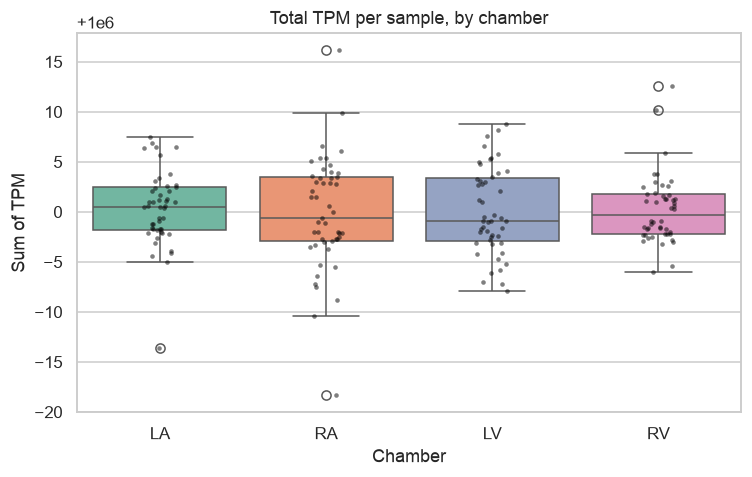

         count       mean  std       min       25%        50%        75%  \
chamber                                                                    
LA        48.0  1000000.0  4.0  999986.0  999998.0  1000001.0  1000002.0   
RA        49.0  1000000.0  6.0  999982.0  999997.0   999999.0  1000004.0   
LV        48.0  1000000.0  4.0  999992.0  999997.0   999999.0  1000003.0   
RV        48.0  1000000.0  3.0  999994.0  999998.0  1000000.0  1000002.0   

               max  
chamber             
LA       1000007.0  
RA       1000016.0  
LV       1000009.0  
RV       1000013.0  


In [7]:
qc = meta.copy()
qc["tpm_sum"] = expr.sum(axis=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=qc, x="chamber", y="tpm_sum", hue="chamber",
            order=CHAMBERS, palette=PALETTE, legend=False, ax=ax)
sns.stripplot(data=qc, x="chamber", y="tpm_sum", order=CHAMBERS,
              color="black", size=3, alpha=0.5, ax=ax)
ax.set(title="Total TPM per sample, by chamber", xlabel="Chamber", ylabel="Sum of TPM")
plt.tight_layout()
plt.show()

print(qc.groupby("chamber", observed=True)["tpm_sum"].describe().round(0))

## 4. Filter and transform

### 4.1 Drop genes that are essentially absent

Keep a gene if it exceeds 1 TPM in at least 2 samples.

In [8]:
keep = (expr > 1).sum(axis=1) >= 2

print(f"genes before : {len(keep):,}")
print(f"genes removed: {(~keep).sum():,}")
print(f"genes kept   : {keep.sum():,}")

expr_f = expr.loc[keep]

genes before : 24,153
genes removed: 7,243
genes kept   : 16,910


### 4.2 log1p

Expression data spans several orders of magnitude. `log1p(x)` computes
`log(1 + x)`, which handles zeros gracefully — `log(0)` is undefined, but
`log1p(0)` is 0.

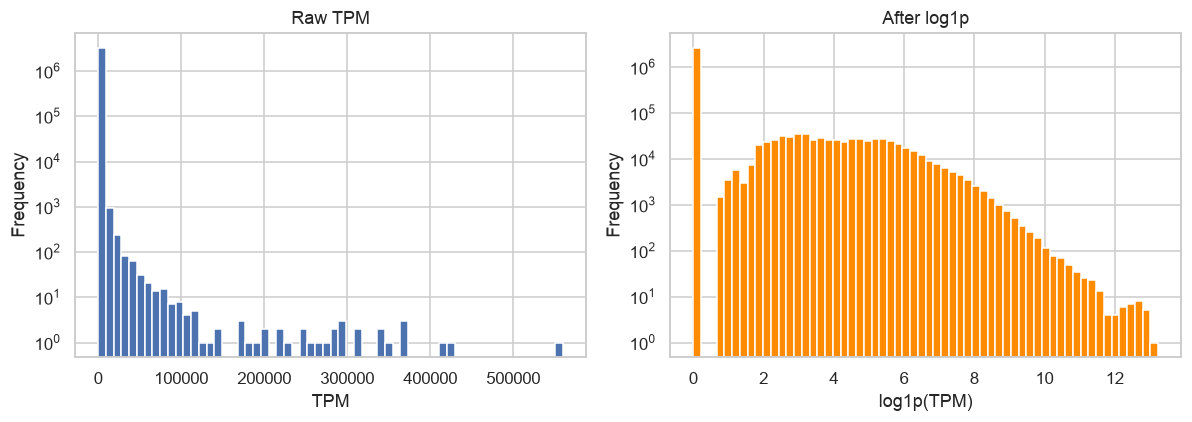

In [9]:
log_tpm = np.log1p(expr_f)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(expr_f.values.flatten(), bins=60)
axes[0].set(title="Raw TPM", xlabel="TPM", ylabel="Frequency", yscale="log")
axes[1].hist(log_tpm.values.flatten(), bins=60, color="darkorange")
axes[1].set(title="After log1p", xlabel="log1p(TPM)", ylabel="Frequency", yscale="log")
plt.tight_layout()
plt.show()

### 4.3 The most highly expressed genes

In [10]:
top10 = log_tpm.mean(axis=1).nlargest(10)
print("top 10 genes by mean expression:")
print(top10.round(3))

top 10 genes by mean expression:
Gene
MYL7      9.352
FTH1      8.652
ACTC1     8.520
EEF1A1    8.471
TPM1      8.431
MYL6      8.309
RPLP1     8.271
GAPDH     8.250
TMSB10    8.194
HSPB1     8.181
dtype: float64


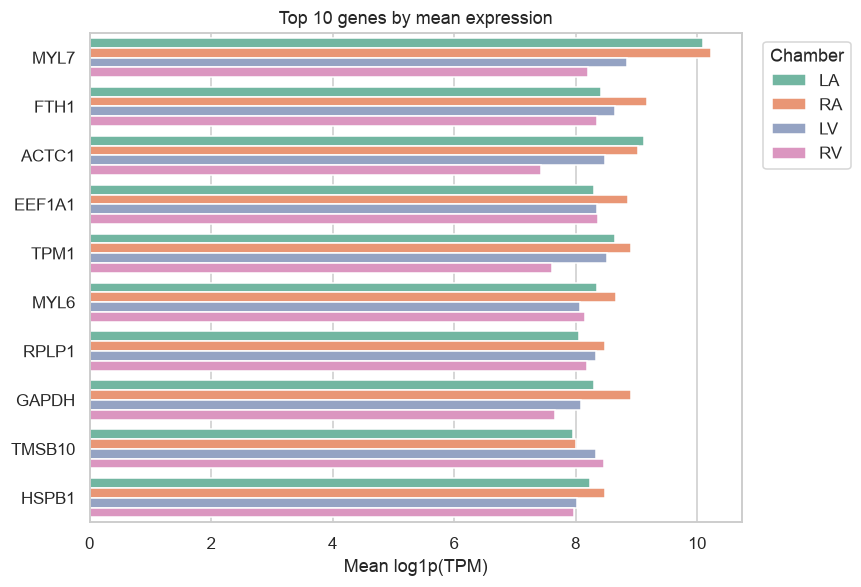

In [11]:
top_long = (
    log_tpm.loc[top10.index]
    .T.join(meta["chamber"])
    .melt(id_vars="chamber", var_name="Gene", value_name="log1p_tpm")
)

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.barplot(data=top_long, y="Gene", x="log1p_tpm", hue="chamber",
            order=top10.index, hue_order=CHAMBERS, palette=PALETTE,
            errorbar=None, ax=ax)
ax.set(title="Top 10 genes by mean expression", xlabel="Mean log1p(TPM)", ylabel="")
ax.legend(title="Chamber", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

These are mostly mitochondrial and sarcomeric genes — exactly what you expect to
dominate heart tissue. A good sign that the data is what it claims to be.

## 5. Chamber-averaged expression and correlation

Average each gene within each chamber, then ask how similar the four chambers
are to each other.

In [12]:
chamber_means = log_tpm.T.join(meta["chamber"]).groupby("chamber", observed=True).mean().T
chamber_means = chamber_means[CHAMBERS]
# The transpose + groupby drops the index name; restore it so that later
# .reset_index() calls produce a column called "Gene" rather than "index".
chamber_means.index.name = "Gene"
chamber_means.columns.name = None

print(f"gene x chamber matrix: {chamber_means.shape}")
chamber_means.head(3).round(3)

gene x chamber matrix: (16910, 4)


,LA,RA,LV,RV
Gene,,,,
A1BG-AS1,0.526,0.293,0.000,0.000
A2M,1.323,0.000,0.181,0.460
A2M-AS1,0.000,0.131,0.000,0.244


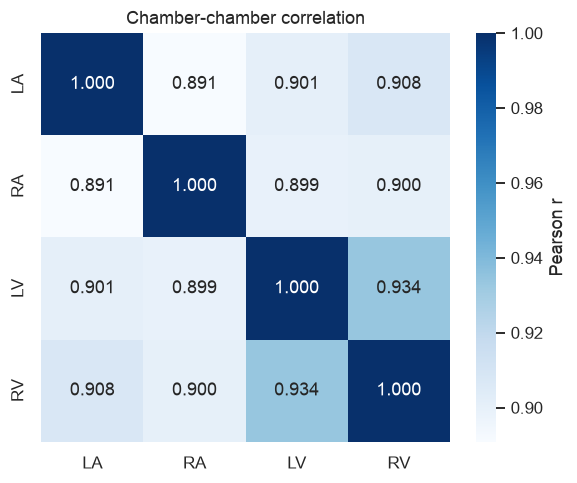

All four chambers are highly correlated — they are all heart muscle.
The interesting signal is in the small differences, not the big similarity.


In [13]:
corr = chamber_means.corr(method="pearson")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="Blues",
            square=True, vmin=corr.values.min(), vmax=1.0,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set(title="Chamber-chamber correlation")
plt.tight_layout()
plt.show()

print("All four chambers are highly correlated — they are all heart muscle.")
print("The interesting signal is in the small differences, not the big similarity.")

## 6. Chamber-biased genes

Now the biology. We contrast the two atria against each other, and the two
ventricles against each other, by subtracting the mean expression.

In [14]:
contrasts = {
    "LA vs RA (atria)": ("LA", "RA"),
    "LV vs RV (ventricles)": ("LV", "RV"),
}

biased = {}
for title, (a, b) in contrasts.items():
    d = pd.DataFrame({
        a: chamber_means[a],
        b: chamber_means[b],
        "delta": chamber_means[a] - chamber_means[b],
    })
    d["abs_delta"] = d["delta"].abs()
    biased[title] = d.sort_values("abs_delta", ascending=False)
    print(f"\n--- {title}: 10 most biased genes ---")
    print(biased[title].head(10)[[a, b, "delta"]].round(3))


--- LA vs RA (atria): 10 most biased genes ---
                 LA     RA  delta
Gene                             
ABCC9         6.611  2.919  3.692
L2HGDH        5.497  1.845  3.652
LOC100129434  6.243  2.901  3.342
LOC102724699  6.765  3.448  3.317
INMT          4.758  1.484  3.274
PARP15        5.663  2.422  3.241
ORC4          5.234  2.064  3.169
METTL21A      6.476  3.311  3.165
FOXK1         6.914  3.786  3.128
MYH7          1.547  4.615 -3.068

--- LV vs RV (ventricles): 10 most biased genes ---
          LV     RV  delta
Gene                      
LYZ    6.160  1.749  4.411
MPO    5.230  0.951  4.279
SPP1   1.172  4.695 -3.523
CCL4   0.337  3.078 -2.741
CCL3   0.472  3.086 -2.614
CXCL8  1.218  3.831 -2.613
MT3    3.722  1.156  2.566
IL1B   0.485  3.045 -2.560
PLAC8  2.759  0.365  2.394
RRM2   3.025  0.640  2.385


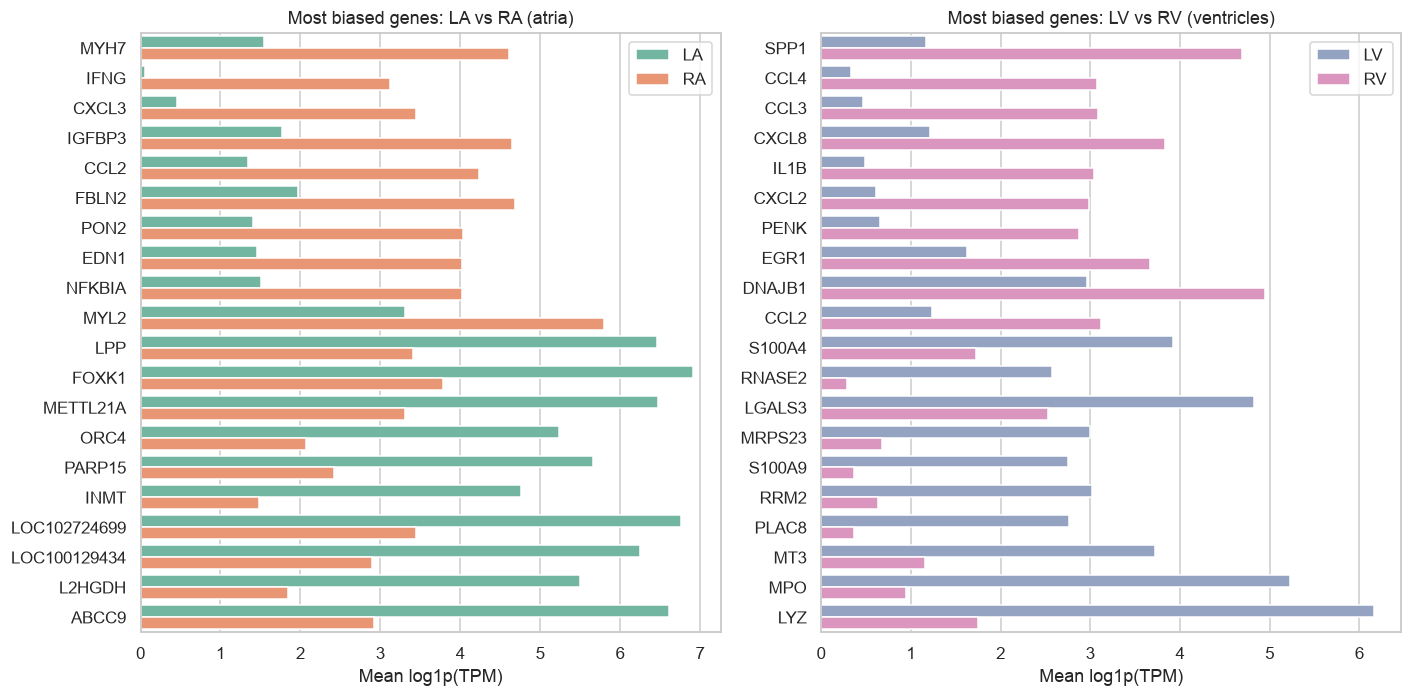

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

for ax, (title, (a, b)) in zip(axes, contrasts.items()):
    d = biased[title]
    top = pd.concat([d.nlargest(10, "delta"), d.nsmallest(10, "delta")])
    plot_df = (
        top[[a, b]].reset_index()
        .melt(id_vars="Gene", var_name="chamber", value_name="mean_log1p")
    )
    order = top.sort_values("delta").index
    sns.barplot(data=plot_df, y="Gene", x="mean_log1p", hue="chamber",
                order=order, palette=PALETTE, ax=ax)
    ax.set(title=f"Most biased genes: {title}", xlabel="Mean log1p(TPM)", ylabel="")
    ax.legend(title="")

plt.tight_layout()
plt.show()

## 7. A single gene across all four chambers

`NOTCH1` is essential for cardiac development and is mutated in several forms of
congenital heart disease — the same disease family as the CHD gene list in S3.

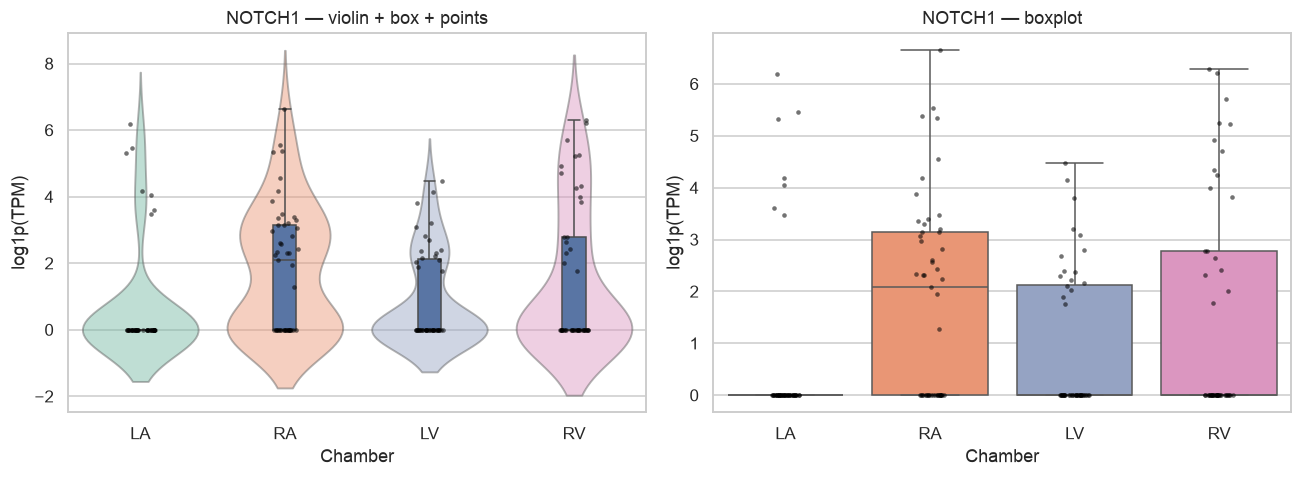

         count   mean    std  min  25%    50%    75%    max
chamber                                                    
LA        48.0  0.672  1.686  0.0  0.0  0.000  0.000  6.184
RA        49.0  1.827  1.905  0.0  0.0  2.083  3.151  6.646
LV        48.0  0.905  1.374  0.0  0.0  0.000  2.118  4.475
RV        48.0  1.488  2.133  0.0  0.0  0.000  2.782  6.291


In [16]:
GENE = "NOTCH1"
assert GENE in log_tpm.index, f"{GENE} not found"

gene_df = meta.copy()
gene_df["expression"] = log_tpm.loc[GENE]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.violinplot(data=gene_df, x="chamber", y="expression", hue="chamber",
               order=CHAMBERS, palette=PALETTE, legend=False,
               inner=None, alpha=0.45, ax=axes[0])
sns.boxplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS,
            width=0.16, showfliers=False, boxprops={"zorder": 2}, ax=axes[0])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS,
              color="black", size=3, alpha=0.55, ax=axes[0])
axes[0].set(title=f"{GENE} — violin + box + points", xlabel="Chamber",
            ylabel="log1p(TPM)")

sns.boxplot(data=gene_df, x="chamber", y="expression", hue="chamber",
            order=CHAMBERS, palette=PALETTE, legend=False,
            showfliers=False, ax=axes[1])
sns.stripplot(data=gene_df, x="chamber", y="expression", order=CHAMBERS,
              color="black", size=3, alpha=0.55, ax=axes[1])
axes[1].set(title=f"{GENE} — boxplot", xlabel="Chamber", ylabel="log1p(TPM)")

plt.tight_layout()
plt.show()

print(gene_df.groupby("chamber", observed=True)["expression"].describe().round(3))

## 8. Pairwise statistical comparison

Six pairwise comparisons between four chambers means six chances of a false
positive, so we correct with Benjamini-Hochberg.

> R does this in one call: `pairwise.wilcox.test(..., p.adjust.method = "BH")`.
> Python needs two steps — the tests, then the correction — which makes the
> multiple-testing step visible instead of hidden in a default argument.

In [17]:
from itertools import combinations
from statsmodels.stats.multitest import multipletests

rows = []
for a, b in combinations(CHAMBERS, 2):
    x = gene_df.loc[gene_df["chamber"] == a, "expression"]
    y = gene_df.loc[gene_df["chamber"] == b, "expression"]
    u = stats.mannwhitneyu(x, y, alternative="two-sided")
    rows.append({
        "group1": a, "group2": b,
        "n1": len(x), "n2": len(y),
        "median1": x.median(), "median2": y.median(),
        "U": u.statistic, "p_raw": u.pvalue,
    })

pw = pd.DataFrame(rows)
pw["p_adj"] = multipletests(pw["p_raw"], method="fdr_bh")[1]
pw["significant"] = pw["p_adj"] < 0.05
pw = pw.sort_values("p_adj").reset_index(drop=True)

print(f"pairwise comparisons of {GENE} expression (BH-corrected):")
print(pw.round(4).to_string(index=False))

pairwise comparisons of NOTCH1 expression (BH-corrected):
group1 group2  n1  n2  median1  median2      U  p_raw  p_adj  significant
    LA     RA  48  49   0.0000   2.0832  762.0 0.0005 0.0028         True
    RA     LV  49  48   2.0832   0.0000 1506.0 0.0090 0.0269         True
    LA     RV  48  48   0.0000   0.0000  903.0 0.0183 0.0366         True
    LA     LV  48  48   0.0000   0.0000  983.0 0.0991 0.1486        False
    RA     RV  49  48   2.0832   0.0000 1325.0 0.2440 0.2928        False
    LV     RV  48  48   0.0000   0.0000 1030.0 0.2976 0.2976        False


## 9. Export a report

Top 50 genes per chamber, one worksheet per chamber — the equivalent of the R
lesson's `openxlsx` workbook loop.

In [18]:
TOP_N = 50
report_file = OUT / "TopGenes_perChamber.xlsx"

with pd.ExcelWriter(report_file, engine="openpyxl") as writer:
    for chamber in CHAMBERS:
        top = (
            chamber_means[chamber]
            .nlargest(TOP_N)
            .rename("mean_log1p_tpm")
            .reset_index()
        )
        top.insert(0, "rank", range(1, len(top) + 1))
        top.to_excel(writer, sheet_name=chamber, index=False)

print(f"wrote {report_file} ({report_file.stat().st_size:,} bytes)")

check = pd.read_excel(report_file, sheet_name=None)
print(f"sheets written: {list(check.keys())}")
print(f"rows per sheet: {[len(v) for v in check.values()]}")
print("\nLA sheet, first rows:")
print(check["LA"].head().round(3))

wrote ../results/py/TopGenes_perChamber.xlsx (12,399 bytes)


sheets written: ['LA', 'RA', 'LV', 'RV']
rows per sheet: [50, 50, 50, 50]

LA sheet, first rows:
   rank   Gene  mean_log1p_tpm
0     1   MYL7          10.105
1     2  ACTC1           9.130
2     3   NPPA           8.841
3     4   TPM1           8.657
4     5   FTH1           8.417


> **On output paths.** We write to `results/py/`, a fixed location relative to
> this notebook. The R version of this lesson used `getwd()`, which meant the
> file landed wherever the notebook happened to be run from — and in practice
> ended up written to two different folders. Always anchor your output paths.

## 10. Where to go next: functional enrichment

You now have a ranked gene list per chamber. The obvious next question is what
those genes *do*.

Paste one of the exported sheets into **Enrichr** (<https://maayanlab.cloud/Enrichr/>)
to test it against GO terms, pathways and disease annotations.

To do it in Python instead, `gseapy` wraps the same service:

```python
# pip install gseapy
import gseapy as gp
enr = gp.enrichr(
    gene_list=chamber_means["LA"].nlargest(200).index.tolist(),
    gene_sets=["GO_Biological_Process_2023", "KEGG_2021_Human"],
    organism="human",
)
enr.results.head(10)
```

We leave this as an exercise because it needs internet access at run time.

## 11. Exercises

1. How many genes are expressed above 1 TPM in *every* sample?
2. Redo the chamber correlation with Spearman instead of Pearson. Does the
   picture change? What would it mean if it did?
3. Compare atria (LA + RA) against ventricles (LV + RV) instead of the
   within-pair contrasts. Which genes separate them most strongly?
4. Pick another CHD gene — `GATA4`, `TBX5` or `NKX2-5` — and repeat sections 7
   and 8 for it.
5. The top-expressed genes are dominated by mitochondrial transcripts. Remove
   genes whose name starts with `MT-` and redo section 4.3. Does the biology
   become more informative?

## 12. Session information

In [19]:
import session_info

session_info.show()